# Taylor Rule vs Bank of England Policy

## Research Question

How closely has UK monetary policy followed a simplified Taylor Rule benchmark since 2000?

## Project Aim

This project uses Python and UK macroeconomic data to construct a simplified Taylor Rule benchmark and compare it with the Bank of England's actual Bank Rate.

The analysis will investigate periods where actual monetary policy diverged from the Taylor Rule benchmark, explore possible economic explanations for these differences, and use a simple sensitivity analysis to examine how the results depend on key model assumptions.

## 1. Economic Background

### Monetary Policy

The Bank of England uses monetary policy to influence economic conditions, with the Bank Rate being its main policy interest rate. Changes in the Bank Rate affect borrowing costs, saving incentives and spending decisions throughout the economy.

One of the key objectives of monetary policy is to maintain price stability. The Bank of England's inflation target is **2%**, measured using the Consumer Prices Index (CPI).

### The Taylor Rule

The Taylor Rule is a simple framework for thinking about how a central bank might set interest rates in response to inflation and economic conditions.

The basic economic intuition is:

* When inflation is above its target, higher interest rates may be appropriate to reduce inflationary pressure.
* When unemployment is unusually high, lower interest rates may be appropriate to boost economic activity.

The Taylor Rule therefore provides a useful benchmark against which actual monetary policy can be compared.

Importantly, the Taylor Rule is a **benchmark rather than a rule that the Bank of England is required to follow**. Actual monetary policy considers a much wider range of economic information.

### The Simplified Taylor Rule

The traditional Taylor Rule incorporates an output gap. For this project, we use a simplified version that replaces the output gap with an unemployment gap:

$$
i_t = r^* + \pi_t + 0.5(\pi_t-\pi^*) + 0.5(U^*-U_t)
$$

Where:

* $i_t$ = Taylor Rule-implied interest rate
* $r^*$ = neutral real interest rate
* $\pi_t$ = current inflation rate
* $\pi^*$ = inflation target
* $U^*$ = assumed natural rate of unemployment
* $U_t$ = current unemployment rate

The model implies that higher inflation relative to its target should lead to a higher suggested interest rate, while higher unemployment relative to its assumed natural rate should lead to a lower suggested interest rate.

### Why use unemployment instead of the output gap?

The original Taylor Rule uses the output gap, which measures the difference between actual and potential economic output. This project uses the unemployment gap instead as a simpler way to measure how much spare capacity there is in the economy.

This makes the project more manageable using readily available UK data. The choice is also an important limitation of the model, which will be discussed later.


## 2. Model Assumptions

To calculate the Taylor Rule, we need to make assumptions about three key variables:

* **Inflation target $\pi^*$ = 2%**
  This is the Bank of England's official inflation target.

* **Neutral real interest rate $r^*$ = 2%**
The 2% value follows the traditional calibration of the Taylor Rule. However, this is not a UK-specific estimate, and the neutral real interest rate cannot be directly observed and may change over time. Therefore, 2% is used as a simplifying assumption for this analysis.

* **Natural unemployment rate $U^*$ = 4.5%**
The 4.5% value is broadly consistent with recent Bank of England estimates of the medium-term equilibrium unemployment rate. However, this rate cannot be directly observed and may change over time, so 4.5% is treated as a simplifying assumption for this analysis.

## 3. Data and Sources

To calculate the simplified Taylor Rule, three UK macroeconomic variables are required:

* **Bank Rate:** the Bank of England's policy interest rate and the actual interest rate against which the Taylor Rule benchmark will be compared.
* **CPI inflation:** the annual percentage change in the Consumer Prices Index, used to measure inflation.
* **Unemployment rate:** the UK unemployment rate, used to represent labour-market conditions in place of the traditional output gap.

The analysis will use monthly data from approximately 2000 onwards. The data will be obtained from official UK sources, primarily the Bank of England and the Office for National Statistics (ONS).

Using official data sources helps ensure that the analysis is based on reliable and appropriately defined economic measures.

## 4. Python Code

### 4.1 Setup

In [274]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

### 4.2 Data Preparation

The analysis uses three monthly UK macroeconomic datasets:

* Bank of England Bank rate
* CPI Inflation
* Unemployment Rate

The datasets are cleaned and then merged using the date.

#### 4.2.1 Bank Rate

In [275]:
# Load the Bank of England Bank Rate dataset
bank_rate = pd.read_csv("bank_rate.csv")

# Convert dates into a format Python can work with
bank_rate["Date"] = pd.to_datetime(
    bank_rate["Date"],
    format="%d %b %y"
)

# Convert dates to the first day of each month
bank_rate["Date"] = bank_rate["Date"].dt.to_period("M").dt.to_timestamp()

# Sort observations chronologically
bank_rate = bank_rate.sort_values("Date")

# Rename columns to simple names
bank_rate.columns = ["Date", "Bank_Rate"]

# Check the cleaned dataset
bank_rate.head()

,Date,Bank_Rate
319,2000-01-01,5.6625
318,2000-02-01,5.9167
317,2000-03-01,6.0000
316,2000-04-01,6.0000
315,2000-05-01,6.0000


#### 4.2.2 CPI Inflation

In [276]:
# Load the CPI inflation dataset
cpi = pd.read_csv("cpi.csv")

# Convert monthly dates into a usable date format
cpi["Date"] = pd.to_datetime(
    cpi["Title"],
    format="%Y %b",
    errors="coerce"
)

# Keep only monthly observations
cpi_monthly = cpi[cpi["Date"].notna()].copy()

# Keep the period covered by our Bank Rate data
cpi_monthly = cpi_monthly[
    cpi_monthly["Date"] >= "2000-01-01"
]

# Rename the CPI column to make it easier to work with
cpi_monthly = cpi_monthly.rename(
    columns={
        "CPI ANNUAL RATE 00: ALL ITEMS 2015=100": "CPI"
    }
)

# Keep only the columns we need
cpi_monthly = cpi_monthly[["Date", "CPI"]]

# Convert CPI values to numbers
cpi_monthly["CPI"] = pd.to_numeric(cpi_monthly["CPI"])

# Check the cleaned dataset
cpi_monthly.head()

,Date,CPI
326,2000-01-01,0.8
327,2000-02-01,0.9
328,2000-03-01,0.6
329,2000-04-01,0.6
330,2000-05-01,0.5


#### 4.2.3 Unemployment

In [277]:
# Load the unemployment dataset
unemployment = pd.read_csv("unemployment.csv")

# Convert monthly dates into a usable date format
unemployment["Date"] = pd.to_datetime(
    unemployment["Title"],
    format="%Y %b",
    errors="coerce"
)

# Keep only monthly observations
unemployment_monthly = unemployment[
    unemployment["Date"].notna()
].copy()

# Keep the period covered by our Bank Rate data
unemployment_monthly = unemployment_monthly[
    unemployment_monthly["Date"] >= "2000-01-01"
]

# Rename the unemployment column to make it easier to work with
unemployment_monthly = unemployment_monthly.rename(
    columns={
        "Unemployment rate (aged 16 and over, seasonally adjusted): %":
        "Unemployment"
    }
)

# Keep only the columns we need
unemployment_monthly = unemployment_monthly[
    ["Date", "Unemployment"]
]

# Convert unemployment values to numbers
unemployment_monthly["Unemployment"] = pd.to_numeric(
    unemployment_monthly["Unemployment"]
)

# Check the cleaned dataset
unemployment_monthly.head()

,Date,Unemployment
631,2000-01-01,5.8
632,2000-02-01,5.8
633,2000-03-01,5.7
634,2000-04-01,5.6
635,2000-05-01,5.5


#### 4.2.4 Combining the Datasets

In [278]:
# Combine the three datasets using their common Date column
data = pd.merge(bank_rate, cpi_monthly, on="Date")
data = pd.merge(data, unemployment_monthly, on="Date")

# Sort the combined dataset chronologically
data = data.sort_values("Date")

# Check the combined dataset
data.head()

,Date,Bank_Rate,CPI,Unemployment
0,2000-01-01,5.6625,0.8,5.8
1,2000-02-01,5.9167,0.9,5.8
2,2000-03-01,6.0000,0.6,5.7
3,2000-04-01,6.0000,0.6,5.6
4,2000-05-01,6.0000,0.5,5.5


In [279]:
# Check the size of the combined dataset
data.shape

(318, 4)

### 4.3 Taylor Rule Calculation

#### 4.3.1 Model Assumptions

In [280]:
# Set the assumptions used in the Taylor Rule
inflation_target = 2
neutral_rate = 2
natural_unemployment = 4.5

#### 4.3.2 Example Calculation

In [281]:
# Calculate the Taylor Rule rate for January 2000 as an example
example_taylor_rate = (
    neutral_rate
    + 0.8
    + 0.5 * (0.8 - inflation_target)
    + 0.5 * (natural_unemployment - 5.8)
)

example_taylor_rate

1.5499999999999998

#### 4.3.3 Calculate the Taylor Rule Benchmark

In [282]:
# Calculate the Taylor Rule rate for every month
data["Taylor_Rate"] = (
    neutral_rate
    + data["CPI"]
    + 0.5 * (data["CPI"] - inflation_target)
    + 0.5 * (natural_unemployment - data["Unemployment"])
)

# Check the first few Taylor Rule values
data[["Date", "CPI", "Unemployment", "Taylor_Rate"]].head()

,Date,CPI,Unemployment,Taylor_Rate
0,2000-01-01,0.8,5.8,1.55
1,2000-02-01,0.9,5.8,1.70
2,2000-03-01,0.6,5.7,1.30
3,2000-04-01,0.6,5.6,1.35
4,2000-05-01,0.5,5.5,1.25


#### 4.3.4 Calculate the Policy Gap

In [283]:
# Calculate the difference between the actual Bank Rate and the Taylor Rule
data["Policy_Gap"] = data["Bank_Rate"] - data["Taylor_Rate"]

# Check the first few observations
data[["Date", "Bank_Rate", "Taylor_Rate", "Policy_Gap"]].head()

,Date,Bank_Rate,Taylor_Rate,Policy_Gap
0,2000-01-01,5.6625,1.55,4.1125
1,2000-02-01,5.9167,1.70,4.2167
2,2000-03-01,6.0000,1.30,4.7000
3,2000-04-01,6.0000,1.35,4.6500
4,2000-05-01,6.0000,1.25,4.7500


### 4.4 Results and Visualisation

#### 4.4.1 Graph 1: Actual Bank Rate vs Taylor Rule

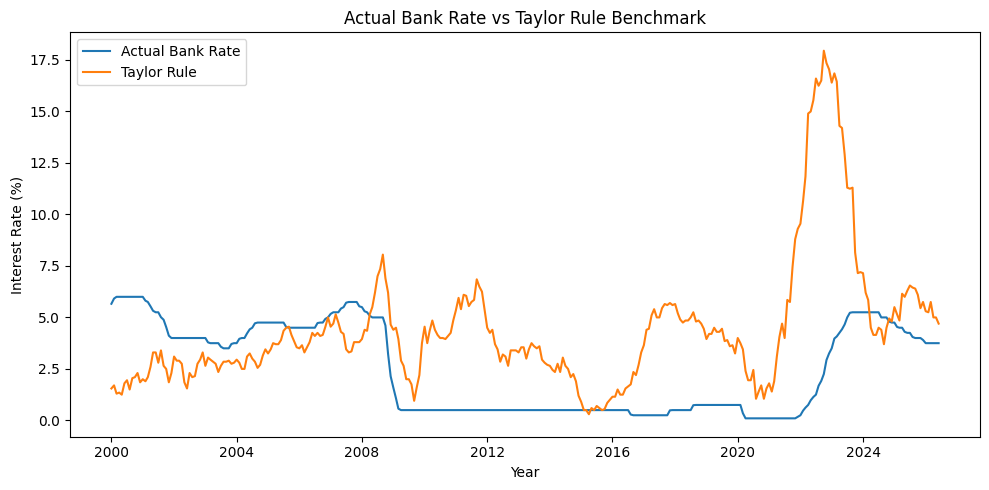

In [284]:
# Plot the actual Bank Rate against the Taylor Rule benchmark
plt.figure(figsize=(10, 5))

plt.plot(
    data["Date"],
    data["Bank_Rate"],
    label="Actual Bank Rate"
)

plt.plot(
    data["Date"],
    data["Taylor_Rate"],
    label="Taylor Rule"
)

plt.title("Actual Bank Rate vs Taylor Rule Benchmark")
plt.xlabel("Year")
plt.ylabel("Interest Rate (%)")
plt.legend()

plt.tight_layout()
plt.show()

#### 4.4.2 Graph 2: Policy Gap

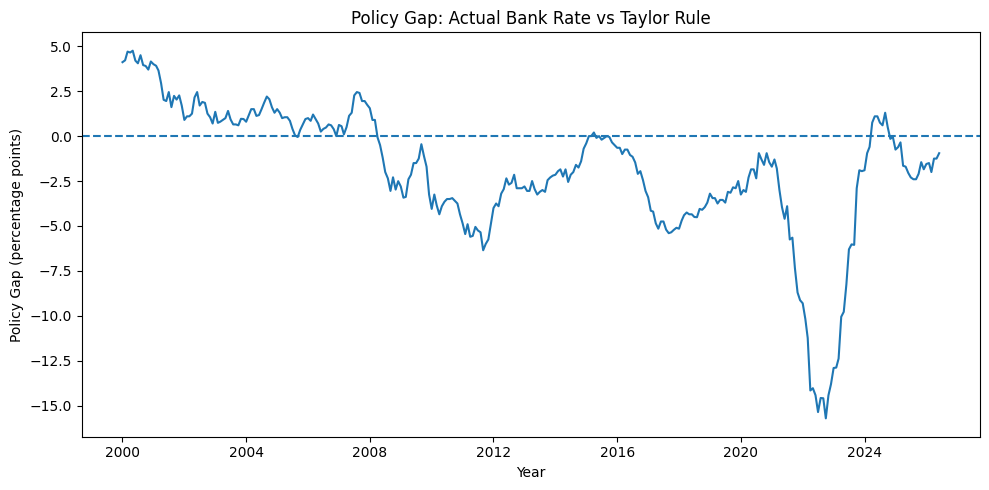

In [285]:
# Plot the difference between actual Bank Rate and the Taylor Rule
plt.figure(figsize=(10, 5))

plt.plot(
    data["Date"],
    data["Policy_Gap"]
)

# Add a zero line to show when the two rates are equal
plt.axhline(0, linestyle="--")

plt.title("Policy Gap: Actual Bank Rate vs Taylor Rule")
plt.xlabel("Year")
plt.ylabel("Policy Gap (percentage points)")

plt.tight_layout()
plt.show()

#### 4.4.3 Graph 3: Inflation and Unemployment

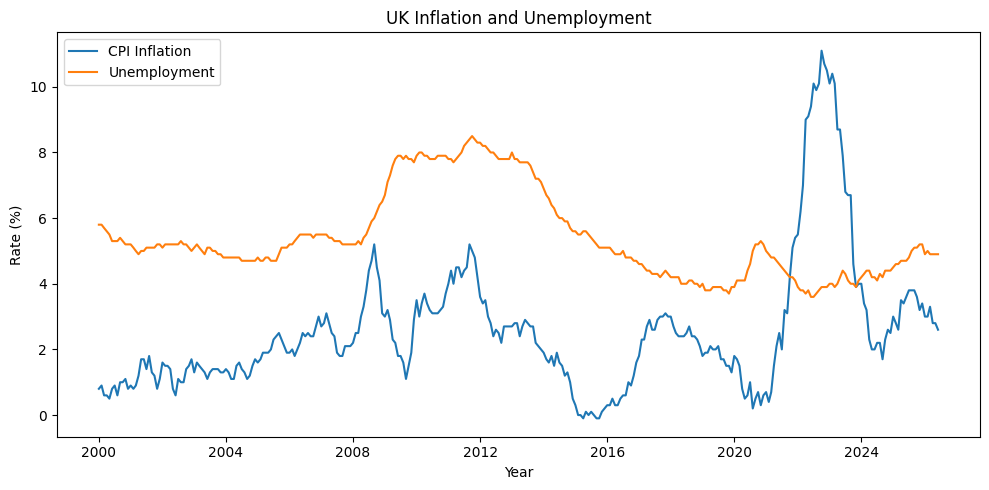

In [286]:
# Plot CPI inflation and unemployment
plt.figure(figsize=(10, 5))

plt.plot(
    data["Date"],
    data["CPI"],
    label="CPI Inflation"
)

plt.plot(
    data["Date"],
    data["Unemployment"],
    label="Unemployment"
)

plt.title("UK Inflation and Unemployment")
plt.xlabel("Year")
plt.ylabel("Rate (%)")
plt.legend()

plt.tight_layout()
plt.show()

#### 4.4.4 Largest Positive and Negative Policy Gaps

In [287]:
# Find the observations with the largest positive and negative policy gaps
largest_positive_gap = data.loc[data["Policy_Gap"].idxmax()]
largest_negative_gap = data.loc[data["Policy_Gap"].idxmin()]

print("Largest positive Policy Gap:")
print(largest_positive_gap)

print("\nLargest negative Policy Gap:")
print(largest_negative_gap)

Largest positive Policy Gap:
Date            2000-05-01 00:00:00
Bank_Rate                       6.0
CPI                             0.5
Unemployment                    5.5
Taylor_Rate                    1.25
Policy_Gap                     4.75
Name: 4, dtype: object

Largest negative Policy Gap:
Date            2022-10-01 00:00:00
Bank_Rate                      2.25
CPI                            11.1
Unemployment                    3.9
Taylor_Rate                   17.95
Policy_Gap                    -15.7
Name: 273, dtype: object


## 5. Economic Interpretation

The policy gap shows substantial differences between the actual Bank Rate and the simplified Taylor Rule benchmark. However, these differences should not be interpreted as evidence that monetary policy was incorrect, because the Taylor Rule used here is a simplified benchmark rather than a description of the Bank of England's actual policy-setting process.

### 5.1 Around 2000

The model produces a relatively large positive policy gap around 2000, with the actual Bank Rate significantly higher than the Taylor Rule benchmark.

This result should be interpreted carefully because the model applies a 2% CPI Inflation target even though the inflation target was 2.5% measured using RPIX between 1997 and 2003. The target changed to 2% measured using CPI in 2003/04.

Therefore, the result reflects a limitation of applying one consistent Taylor Rule specification across a period in which the UK's monetary policy framework changed.

### 5.2 The 2022 Inflation Shock

The largest negative policy gap occurs during the 2022 inflation shock. In October 2022, CPI inflation reached around 11%, while the Bank Rate was 2.25%. The large difference between the inflation rate and its 2% target produced a very high Taylor Rule benchmark.

The Bank of England identified several important sources of the inflation shock, including higher global energy prices, particularly following Russia's invasion of Ukraine, and supply-chain disruption following the pandemic.

These developments help explain why the simplified Taylor Rule and the actual Bank Rate diverged so significantly. The Taylor Rule responds mechanically to current inflation and unemployment, while the economic shock involved large changes to global supply and energy prices that monetary policy could not directly control.

This period therefore highlights an important limitation of the simplified model: a Taylor Rule based only on inflation and unemployment does not capture the causes of inflation or other information available to policymakers.

## 6. Sensitivity Analysis

The Taylor Rule depends on assumptions about the neutral real interest rate and the natural rate of unemployment, neither of which can be directly observed. This section examines how changing these assumptions affects the Taylor Rule benchmark.

The baseline model assumes a neutral real interest rate of 2% and a natural unemployment rate of 4.5%. To test the sensitivity of the results, these assumptions are changed to 1% and 5%, respectively.

In [288]:
# Calculate the Taylor Rule using alternative assumptions
sensitivity = data[["Date", "CPI", "Unemployment"]].copy()

sensitivity["Baseline_Taylor_Rate"] = (
    2
    + sensitivity["CPI"]
    + 0.5 * (sensitivity["CPI"] - 2)
    + 0.5 * (4.5 - sensitivity["Unemployment"])
)

sensitivity["Alternative_Taylor_Rate"] = (
    1
    + sensitivity["CPI"]
    + 0.5 * (sensitivity["CPI"] - 2)
    + 0.5 * (5 - sensitivity["Unemployment"])
)

# Calculate the effect of changing the assumptions
sensitivity["Difference"] = (
    sensitivity["Alternative_Taylor_Rate"]
    - sensitivity["Baseline_Taylor_Rate"]
)

# Compare the two versions
sensitivity[[
    "Date",
    "Baseline_Taylor_Rate",
    "Alternative_Taylor_Rate",
    "Difference"
]].head()

,Date,Baseline_Taylor_Rate,Alternative_Taylor_Rate,Difference
0,2000-01-01,1.55,0.80,-0.75
1,2000-02-01,1.70,0.95,-0.75
2,2000-03-01,1.30,0.55,-0.75
3,2000-04-01,1.35,0.60,-0.75
4,2000-05-01,1.25,0.50,-0.75


The alternative assumptions produce a Taylor Rule benchmark that is 0.75 percentage points lower than the baseline. This demonstrates that the estimated policy benchmark depends on assumptions about unobservable variables such as the neutral real interest rate and natural rate of unemployment. The Taylor Rule should therefore be interpreted as a benchmark rather than a precise estimate of the appropriate policy rate.

## 7. Conclusion

This project constructed a simplified Taylor Rule benchmark using monthly UK data on Bank Rate, CPI inflation and unemployment from 2000 onwards.

The results show that actual Bank Rate sometimes differed substantially from the Taylor Rule benchmark. The largest divergences occurred during periods in which the simplified model did not fully capture the economic environment, including the different monetary policy framework around 2000 and the major inflation shock of 2022.

The 2022 episode particularly highlights the limitations of using a simple Taylor Rule. The benchmark responds mechanically to current inflation and unemployment, while the causes and persistence of inflation can vary substantially over time.

Overall, the analysis suggests that the Taylor Rule can provide a useful benchmark for examining monetary policy, but its results depend on the assumptions and variables included in the model. It should therefore be used as a framework for analysis rather than as a precise measure of the appropriate Bank Rate.

## 8. Limitations and Improvements

There are a few important limitations to this analysis:

- **Using unemployment instead of the output gap:** The original Taylor Rule uses the output gap. Instead, this model uses unemployment as it is simpler to work with and the data is readily available.

- **Some values are assumptions:** The neutral real interest rate and natural unemployment rate cannot be directly observed, so they have to be estimated or assumed.

- **The assumptions stay the same over time:** The model uses the same neutral rate, natural unemployment rate and coefficients throughout the whole period. In reality, these can change over time.

- **The inflation target changed:** A 2% CPI inflation target was used for the entire model, even though the UK's inflation target and inflation measure were different at the beginning of the period.

- **The Taylor Rule is a simplified model:** It only uses inflation and unemployment, so it leaves out other factors that can affect interest rate decisions, such as energy prices, financial conditions and other economic shocks.

- **Different data frequencies:** The unemployment series is a three-month average, while Bank Rate and CPI are monthly measures. This means the three variables are not perfectly comparable at every point in time.

## 9. References

1. **Taylor, J. B. (1993).** *Discretion versus Policy Rules in Practice.* Carnegie-Rochester Conference Series on Public Policy, 39, 195–214. Stanford University.
[Available here](https://web.stanford.edu/~johntayl/Papers/Discretion.PDF)

2. **Bank of England.** *Monetary Policy.*
[Available here](https://www.bankofengland.co.uk/monetary-policy)

3. **Office for National Statistics (ONS).** *CPI annual rate 00: All items 2015=100 (D7G7).* Consumer Price Inflation time series (MM23).
[Available here](https://www.ons.gov.uk/economy/inflationandpriceindices/timeseries/d7g7)

4. **Office for National Statistics (ONS).** *Unemployment rate (aged 16 and over, seasonally adjusted): % (MGSX).* Labour Market Statistics time series (LMS).
[Available here](https://www.ons.gov.uk/employmentandlabourmarket/peoplenotinwork/unemployment/timeseries/mgsx)

5. **Bank of England.** *Data Series: IUMABEDR – Monthly average of official Bank Rate.*
[Available here](https://www.bankofengland.co.uk/boeapps/database/fromshowcolumns.asp?CSVF=TT&DAT=RNG&FD=1&FM=Jan&FNY=Y&FY=2020&Filter=N&FromSeries=1&SeriesCodes=IUMABEDR&TD=1&TM=Jan&TY=2040&ToSeries=50&Travel=NIxAZxSUx&UsingCodes=Y&VPD=Y&html.x=66&html.y=26&title=IUMABEDR&)

6. **Batini, N. and Greenslade, J. (2003).** *Measuring the UK Short-Run NAIRU. Bank of England External MPC Unit Discussion Paper No. 12.*
[Available here](https://www.bankofengland.co.uk/external-mpc-discussion-paper/2003/measuring-the-uk-short-run-nairu)

7. **Bank of England (2025).** *Monetary Policy Report – August 2025.*
[Available here](https://www.bankofengland.co.uk/monetary-policy-report/2025/august-2025)

8. **Bank of England (2024).** *Monetary Policy Report – February 2024.*
[Available here](https://www.bankofengland.co.uk/monetary-policy-report/2024/february-2024)

9. **Bank of England (2013).** *Inflation Targeting and Flexibility.*
[Available here](https://www.bankofengland.co.uk/-/media/boe/files/speech/2013/inflation-targeting-and-flexibility.pdf)

10. **Bank of England (2022).** *Monetary Policy Report – November 2022.*
[Available here](https://www.bankofengland.co.uk/monetary-policy-report/2022/november-2022)